# Sentiment Analysis for Political Campaign
Analyzing sentiment in BJP and Congress tweets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## Load Data

In [2]:
# Load BJP tweets
bjp_df = pd.read_csv('bjp_tweets.csv')
print(f'BJP tweets shape: {bjp_df.shape}')
print(f'Columns: {bjp_df.columns.tolist()}')
print(f'\nFirst few rows:')
print(bjp_df.head())
print(f'\nTarget distribution:')
print(bjp_df['target'].value_counts())

BJP tweets shape: (49477, 3)
Columns: ['Unnamed: 0', 'tweet', 'target']

First few rows:
   Unnamed: 0                                              tweet  target
0           0  ndtv anchor let go over to aap live press conf...       0
1           1  sambit patra attacks rahul gandhi over his cow...       0
2           2  crediting the bjp with taking development to s...       1
3           3  ktrbrs do do false allegations on iasassociati...       0
4           4  gujarat assembly yet to get rs cr as gst compe...       1

Target distribution:
target
1    26515
0    22962
Name: count, dtype: int64


In [3]:
# Load Congress tweets
congress_df = pd.read_csv('congress_tweets.csv')
print(f'Congress tweets shape: {congress_df.shape}')
print(f'First few rows:')
print(congress_df.head())
print(f'\nTarget distribution:')
print(congress_df['target'].value_counts())

Congress tweets shape: (30252, 3)
First few rows:
   Unnamed: 0                                              tweet  target
0           0  spending shocker cbo latest debt projection sh...       0
1           1  will you vote for congress in 2024 congress co...       1
2           2        triviapotus we need termlimits for congress       1
3           3  eam s jaishankar hit out at congress for quad ...       0
4           4  is this why congress supported amp celebrated ...       1

Target distribution:
target
1    16012
0    14240
Name: count, dtype: int64


In [4]:
# Combine datasets
combined_df = pd.concat([bjp_df, congress_df], ignore_index=True)
print(f'Combined dataset shape: {combined_df.shape}')
print(f'\nMissing values:')
print(combined_df.isnull().sum())
print(f'\nTarget distribution:')
print(combined_df['target'].value_counts())

Combined dataset shape: (79729, 3)

Missing values:
Unnamed: 0    0
tweet         0
target        0
dtype: int64

Target distribution:
target
1    42527
0    37202
Name: count, dtype: int64


## Data Preprocessing

In [5]:
# Remove any null values
combined_df = combined_df.dropna(subset=['tweet', 'target'])
print(f'Dataset shape after removing nulls: {combined_df.shape}')

# Convert text to lowercase
combined_df['tweet'] = combined_df['tweet'].str.lower()
print('Text converted to lowercase')

# Display sample tweets
print('\nSample tweets:')
print(combined_df['tweet'].head(3).values)

Dataset shape after removing nulls: (79729, 3)
Text converted to lowercase

Sample tweets:
<StringArray>
[  'ndtv anchor let go over to aap live press conference the next thing you see sanjayazadsln bashing bjp with modiadanibhaibhai probably an awkward moment for everyone in the ndtv news room ca even stop the live stream midway manishsisodia bjp aap',
                                                                                                                          'sambit patra attacks rahul gandhi over his cowardice remark watch video sambitpatra rahulgandhi china newsupdate bjp congress',
 'crediting the bjp with taking development to smaller cities and towns pmmodi said the speed of growth has increased under the double engine govt he said shivamoggaairport had been inaugurated at a time when the number of air travellers was rising']
Length: 3, dtype: str


## Feature Extraction and Model Training

In [6]:
# Split data
X = combined_df['tweet']
y = combined_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

Training set size: 63783
Test set size: 15946


In [7]:
# Feature extraction using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f'TF-IDF training matrix shape: {X_train_tfidf.shape}')
print(f'TF-IDF test matrix shape: {X_test_tfidf.shape}')

TF-IDF training matrix shape: (63783, 5000)
TF-IDF test matrix shape: (15946, 5000)


## Model 1: Naive Bayes

In [8]:
# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluation
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Naive Bayes Accuracy: {nb_accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7352

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.72      0.72      7405
           1       0.75      0.75      0.75      8541

    accuracy                           0.74     15946
   macro avg       0.73      0.73      0.73     15946
weighted avg       0.74      0.74      0.74     15946



## Model 2: Logistic Regression

In [9]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8097

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      7405
           1       0.81      0.84      0.82      8541

    accuracy                           0.81     15946
   macro avg       0.81      0.81      0.81     15946
weighted avg       0.81      0.81      0.81     15946



## Model Comparison

Model Comparison:
                 Model  Accuracy
0          Naive Bayes  0.735169
1  Logistic Regression  0.809670


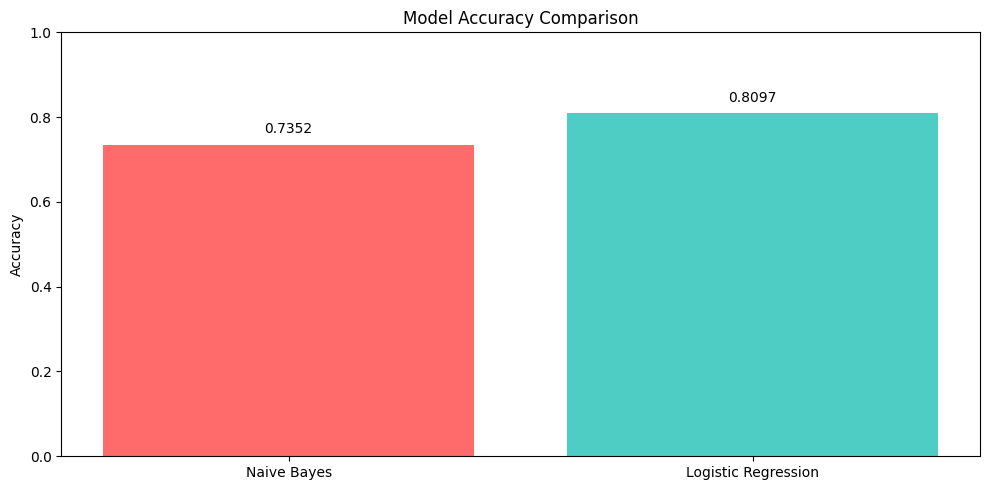


Best Model: Logistic Regression with accuracy 0.8097


In [10]:
# Compare models
models = ['Naive Bayes', 'Logistic Regression']
accuracies = [nb_accuracy, lr_accuracy]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print('Model Comparison:')
print(comparison_df)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.bar(models, accuracies, color=['#FF6B6B', '#4ECDC4'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim([0, 1])
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(f'\nBest Model: {models[np.argmax(accuracies)]} with accuracy {max(accuracies):.4f}')

## Confusion Matrix Visualization

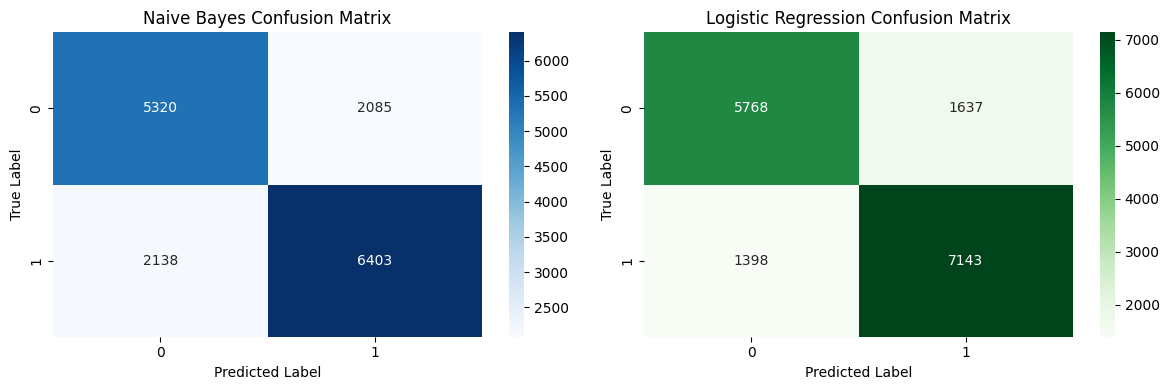

In [11]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Sentiment Prediction on Sample Data

In [12]:
# Use the best model (Logistic Regression) for predictions
best_model = lr_model

# Sample tweets for prediction
sample_tweets = [
    'great leadership and development',
    'poor governance and corruption',
    'amazing performance by the government',
    'disappointing policies'
]

sample_tfidf = vectorizer.transform(sample_tweets)
sample_predictions = best_model.predict(sample_tfidf)

print('Sample Sentiment Predictions:')
for tweet, prediction in zip(sample_tweets, sample_predictions):
    sentiment = 'Positive' if prediction == 1 else 'Negative'
    print(f'Tweet: "{tweet}" -> Sentiment: {sentiment}')

Sample Sentiment Predictions:
Tweet: "great leadership and development" -> Sentiment: Positive
Tweet: "poor governance and corruption" -> Sentiment: Negative
Tweet: "amazing performance by the government" -> Sentiment: Positive
Tweet: "disappointing policies" -> Sentiment: Positive


## Summary

In [13]:
print('='*60)
print('SENTIMENT ANALYSIS SUMMARY')
print('='*60)
print(f'Total tweets analyzed: {len(combined_df)}')
print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')
print(f'\nClass distribution in dataset:')
print(f'  Positive (1): {(y == 1).sum()} tweets')
print(f'  Negative (0): {(y == 0).sum()} tweets')
print(f'\nModel Performance:')
print(f'  Naive Bayes Accuracy: {nb_accuracy:.4f}')
print(f'  Logistic Regression Accuracy: {lr_accuracy:.4f}')
print(f'\nBest Model: Logistic Regression')
print('='*60)

SENTIMENT ANALYSIS SUMMARY
Total tweets analyzed: 79729
Training set size: 63783
Test set size: 15946

Class distribution in dataset:
  Positive (1): 42527 tweets
  Negative (0): 37202 tweets

Model Performance:
  Naive Bayes Accuracy: 0.7352
  Logistic Regression Accuracy: 0.8097

Best Model: Logistic Regression
